# UMAP on MNIST and Fashion-MNIST

This notebook is the "classic" UMAP demo: applying it to image data where the class
structure (digits 0-9, or clothing categories) is well known, so it's easy to judge at a
glance whether the embedding is doing something sensible.

We'll:
1. Load MNIST (handwritten digits) and Fashion-MNIST (clothing images)
2. Flatten each image into a feature vector
3. Embed with UMAP and color by true label
4. Compare UMAP against PCA and t-SNE
5. Add brief insights after each plot, interpreting what the shapes actually mean

> **Note:** This notebook downloads data from OpenML the first time it runs (`fetch_openml`),
> so it needs internet access. Run it locally or in Google Colab if your environment
> restricts outbound network access.


## 1. Import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import umap

RANDOM_STATE = 42
np.random.seed(42)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load MNIST and Fashion-MNIST

- `fetch_openml("mnist_784")` pulls the full 70,000-image dataset. 
- UMAP scales well, but for a quick, responsive notebook we'll subsample to
10,000 images — plenty to see clean cluster separation.

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist, y_mnist = mnist.data, mnist.target.astype(int)

# Subsample for speed
X_mnist, _, y_mnist, _ = train_test_split(
    X_mnist, y_mnist, train_size=10_000, stratify=y_mnist, random_state=42
)

# Scale pixel values to [0, 1]
X_mnist = X_mnist / 255.0

print(X_mnist.shape, y_mnist.shape)

(10000, 784) (10000,)


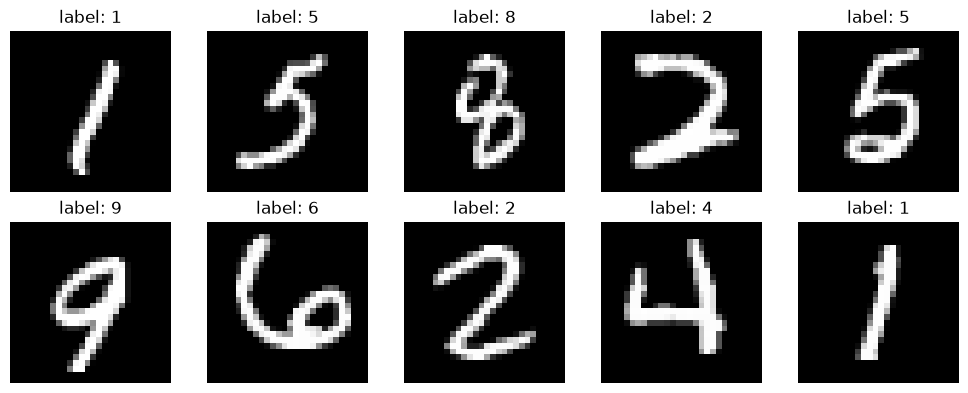

In [3]:
# a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_mnist[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"label: {y_mnist[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

- Each image is just a 784-dimensional vector of pixel intensities.

## 3. UMAP embedding of MNIST

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


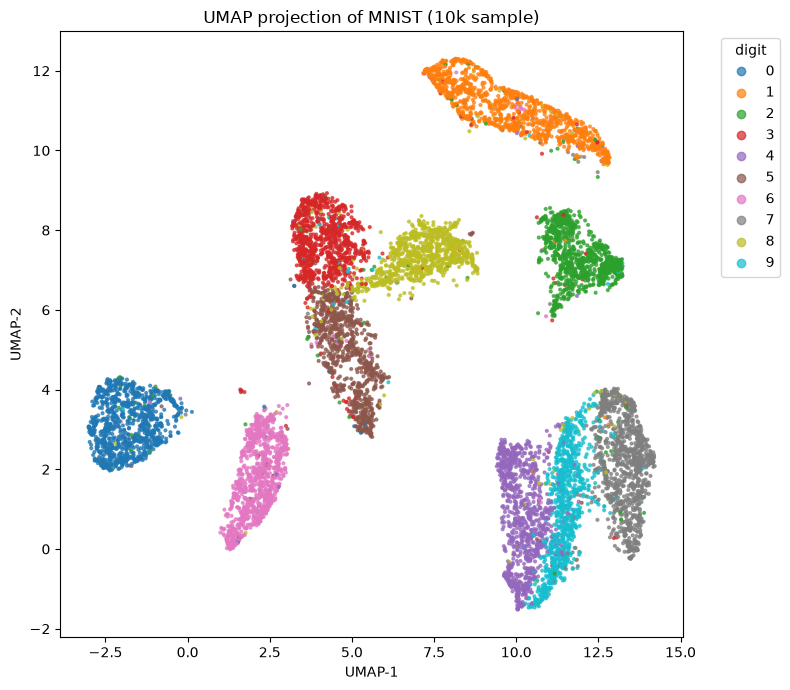

In [4]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
embedding_mnist = reducer.fit_transform(X_mnist)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    embedding_mnist[:, 0], embedding_mnist[:, 1],
    c=y_mnist, cmap="tab10", s=4, alpha=0.7
)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("UMAP projection of MNIST (10k sample)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

- UMAP separates all 10 digits into distinct,
mostly well-isolated islands.
- The digits that end up closest together are exactly the ones that are genuinely easiest to confuse by eye — the embedding is picking up on real visual ambiguity, not noise.

## 4. Compare against PCA and t-SNE

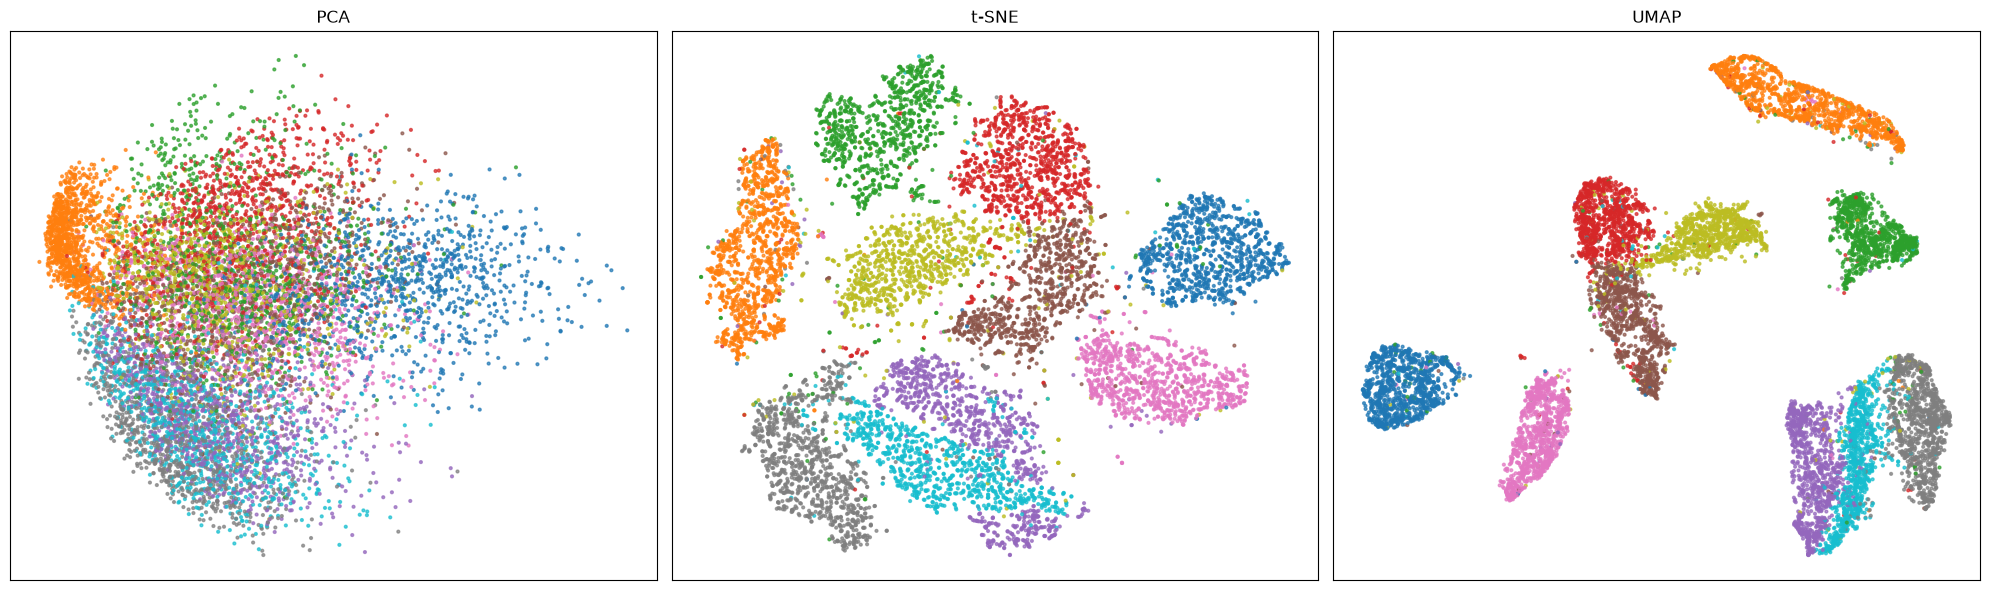

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
embedding_pca = pca.fit_transform(X_mnist)

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30)
embedding_tsne = tsne.fit_transform(X_mnist)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, emb, title in zip(
    axes,
    [embedding_pca, embedding_tsne, embedding_mnist],
    ["PCA", "t-SNE", "UMAP"],
):
    sc_ = ax.scatter(emb[:, 0], emb[:, 1], c=y_mnist, cmap="tab10", s=4, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

**Insight:**
- **PCA** captures only linear variance, so digit classes overlap heavily.
- **t-SNE** and **UMAP** both produce visually tight, well-separated clusters. 
- UMAP typically runs noticeably faster on this size of dataset and tends to keep some rough global
  relationships between clusters, whereas t-SNE optimizes almost purely for local structure and cluster placement can be arbitrary between runs.


## 5. Now Fashion-MNIST

In [6]:
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_fashion, y_fashion = fashion.data, fashion.target.astype(int)

X_fashion, _, y_fashion, _ = train_test_split(
    X_fashion, y_fashion, train_size=10_000, stratify=y_fashion, random_state=RANDOM_STATE
)
X_fashion = X_fashion / 255.0

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(X_fashion.shape, y_fashion.shape)

(10000, 784) (10000,)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


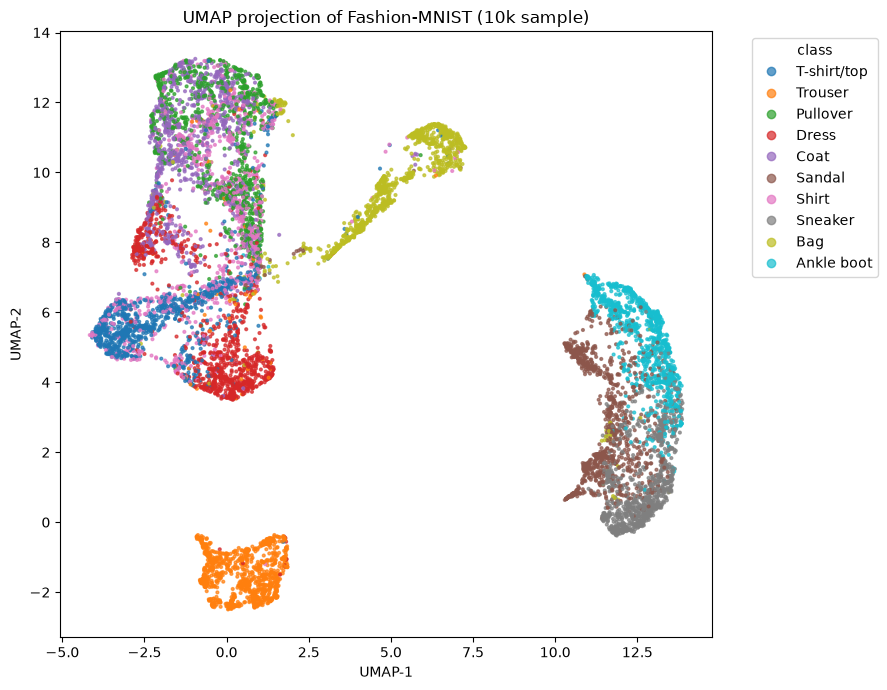

In [7]:
reducer_fashion = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
embedding_fashion = reducer_fashion.fit_transform(X_fashion)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("UMAP projection of Fashion-MNIST (10k sample)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

- The separation here is visibly less clean than on MNIST, and that's actually the
interesting result, not a flaw.
- UMAP is exposing a real limit of the data (2D pixel similarity isn't enough to cleanly separate a shirt from a coat), not failing at its job.

## 6. Effect of UMAP's key parameters

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


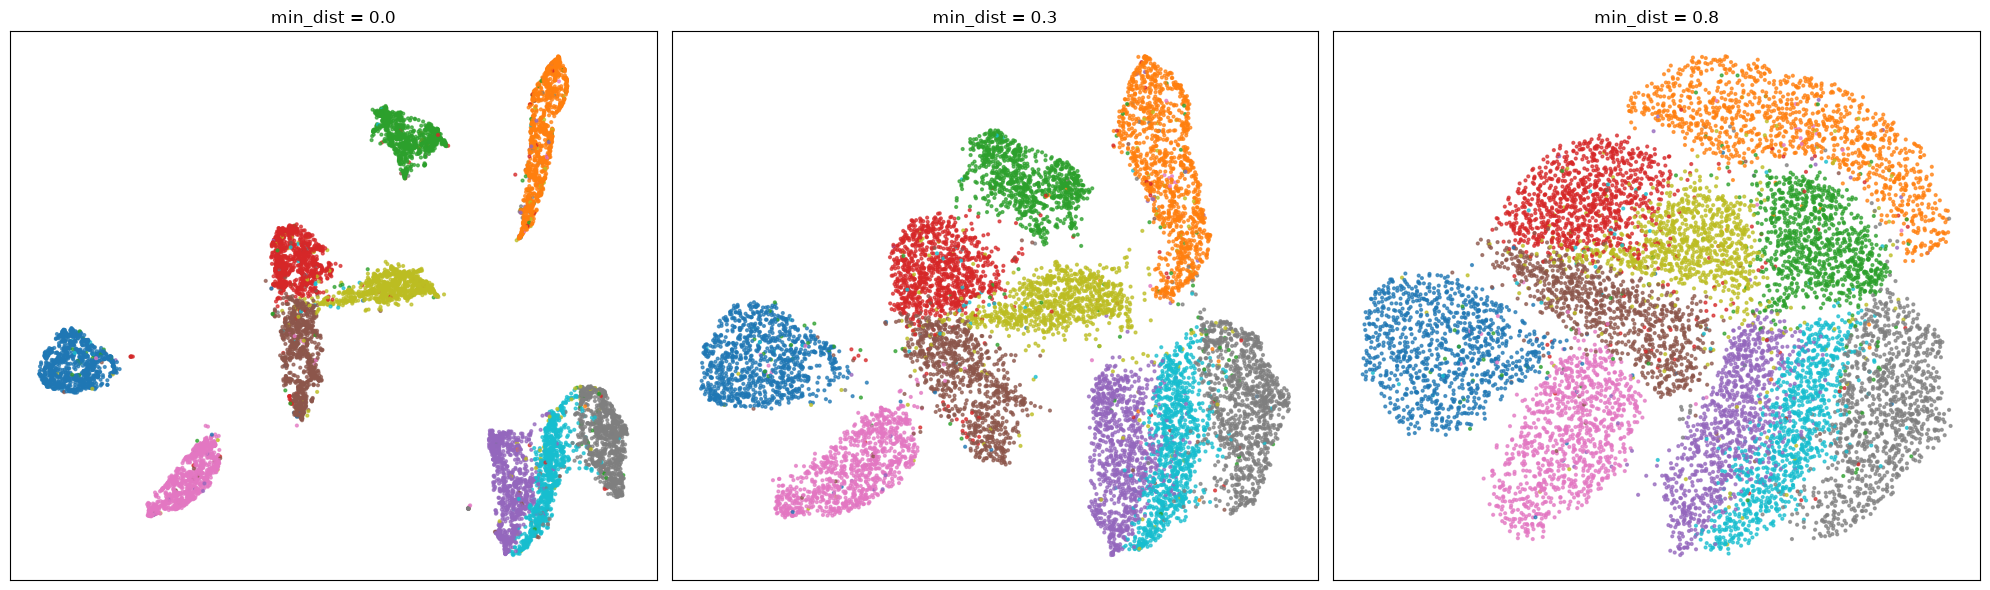

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, min_dist in zip(axes, [0.0, 0.3, 0.8]):
    reducer_p = umap.UMAP(n_neighbors=15, min_dist=min_dist, random_state=RANDOM_STATE)
    emb_p = reducer_p.fit_transform(X_mnist)
    ax.scatter(emb_p[:, 0], emb_p[:, 1], c=y_mnist, cmap="tab10", s=4, alpha=0.7)
    ax.set_title(f"min_dist = {min_dist}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


- `min_dist` controls how tightly points within a cluster are packed. 
- Low values (0.0) produce dense, tight blobs that emphasize fine local structure
- High values (0.8) spread points out and can reveal more of the internal shape of a cluster, at the cost of clusters looking less sharply separated.

## 7. A 3D UMAP embedding of Fashion-MNIST

In [9]:
import plotly.express as px
import pandas as pd

reducer_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=RANDOM_STATE)
embedding_fashion_3d = reducer_3d.fit_transform(X_fashion)

df_3d = pd.DataFrame(embedding_fashion_3d, columns=["UMAP-1", "UMAP-2", "UMAP-3"])
df_3d["class"] = [class_names[int(i)] for i in y_fashion]

fig = px.scatter_3d(
    df_3d, x="UMAP-1", y="UMAP-2", z="UMAP-3",
    color="class", category_orders={"class": class_names},
    opacity=0.7, height=700,
    title="3D UMAP projection of Fashion-MNIST (10k sample) — drag to rotate",
)
fig.update_traces(marker=dict(size=2))
fig.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- In 3D, UMAP can better separate clothing categories that overlap in 2D projections
- The extra dimension reveals more structure within clusters, though Fashion-MNIST remains
more challenging than MNIST due to visual similarity between clothing categories